<a href="https://colab.research.google.com/github/Clestialcosmos/Data_Visualisation/blob/main/DV1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv("/content/DV_Lab1_dataset.csv")

In [44]:
df.head(365)

,Date,Region,Product_Category,Marketing_Spend,Sales_Revenue,Customer_Age,Store_Traffic
0,2023-01-01,East,Accessories,3654.36,14221.79,26,149
1,2023-01-02,West,Software,827.43,3458.11,23,72
2,2023-01-03,North,Software,4198.37,15012.28,42,149
3,2023-01-04,East,Accessories,3678.09,13544.26,24,129
4,2023-01-05,East,Accessories,866.07,4125.04,35,78
...,...,...,...,...,...,...,...
360,2023-12-27,West,Electronics,4424.56,17889.70,25,178
361,2023-12-28,North,Electronics,4694.53,14617.08,18,154
362,2023-12-29,North,Software,3043.10,10007.20,36,105
363,2023-12-30,South,Accessories,3634.93,15004.64,30,153


In [45]:
df.shape

(365, 7)

#Task 1: Bar Chart (Comparison)
<br>
 <h3>● Objective: Compare the total Sales_Revenue across the four different Regions.
 <br>
 ● Instructions: Group the data by Region, calculate the sum of Sales_Revenue, and plot a vertical bar chart. Ensure you add a title and label your axes.


In [46]:
regionSales = df.groupby('Region')['Sales_Revenue'].sum().reset_index()

In [47]:
display(regionSales)

,Region,Sales_Revenue
0,East,904178.60
1,North,890321.37
2,South,821351.95
3,West,1022127.65


Text(0.5, 1.0, 'Total Sales Revenue Across Different Regions')

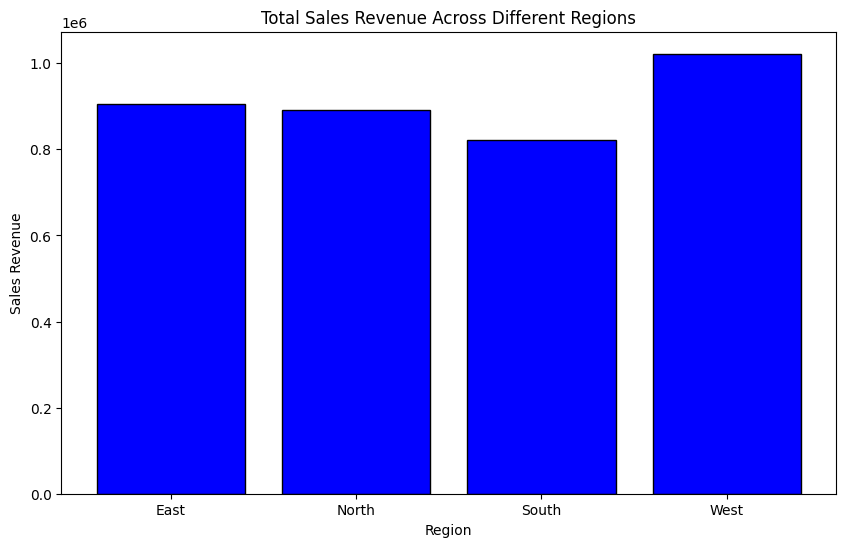

In [48]:
plt.figure(figsize=(10,6))
plt.bar(regionSales['Region'],regionSales['Sales_Revenue'],color = "blue",edgecolor = "Black")
plt.xlabel("Region")
plt.ylabel("Sales Revenue")
plt.title("Total Sales Revenue Across Different Regions")

#Task 2: Line Chart (Trend over Time)
<br> ● Objective: Track the monthly trend of Sales_Revenue.
<br> ● Instructions: First, convert the 'Date' column to a datetime format and extract the month. Group the data by Month to get the total monthly sales, then plot a line chart with markers on each data point.

In [49]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

In [50]:
monthSales = df.groupby('Month')['Sales_Revenue'].sum().reset_index()

Text(0.5, 1.0, 'Monthly Trend of Sales Revenue')

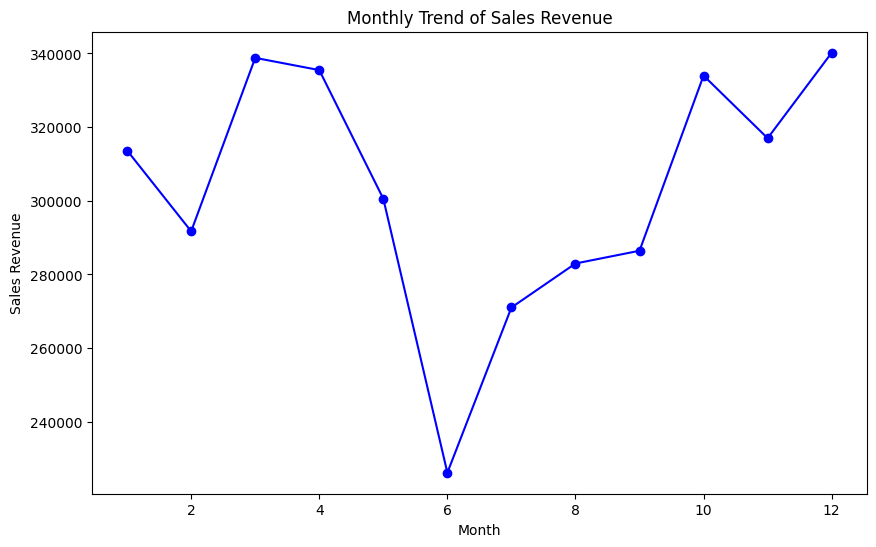

In [51]:
plt.figure(figsize=(10,6))
plt.plot(monthSales['Month'],monthSales['Sales_Revenue'],marker = "o",color = "blue")
plt.xlabel("Month")
plt.ylabel("Sales Revenue")
plt.title("Monthly Trend of Sales Revenue")

#Task 3: Pie Chart (Composition)
<br>● Objective: Show the market share of each Product_Category based on total revenue.
<br>● Instructions: Group the data by Product_Category and sum the Sales_Revenue. Plot a pie chart showing the percentages (use autopct). Explode the slice with the highest revenue.

In [52]:
productCategory = df.groupby('Product_Category')['Sales_Revenue'].sum()
max = productCategory.idxmax()
explode = [0.1 if cat == max else 0 for cat in productCategory.values]

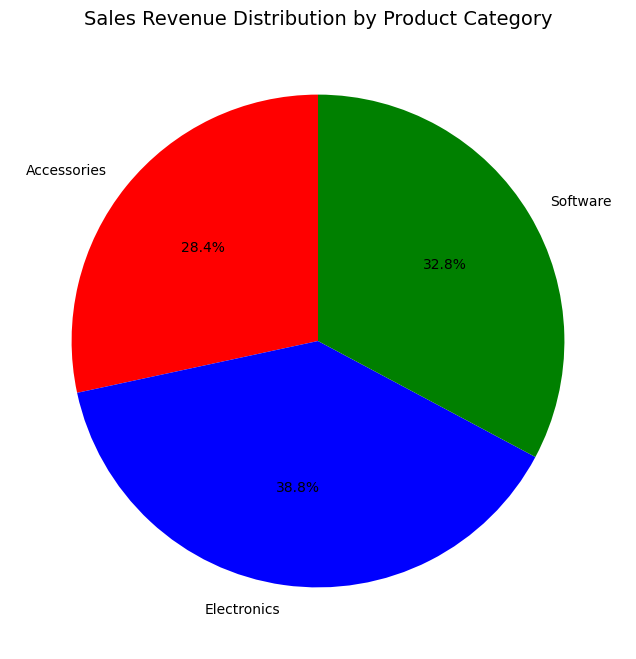

In [53]:
plt.figure(figsize=(8,8))
plt.pie(productCategory.values,
        labels=productCategory.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['Red','Blue','Green','Yellow'])

plt.title("Sales Revenue Distribution by Product Category", fontsize=14)
plt.show()

#Task 4: Scatter Plot (Relationship)
<br>● Objective: Investigate the correlation between Marketing_Spend (X-axis) and Sales_Revenue (Y-axis).
<br>● Instructions: Create a scatter plot with these two continuous numerical variables. Add an alpha (transparency) parameter to easily visualize clustered points.

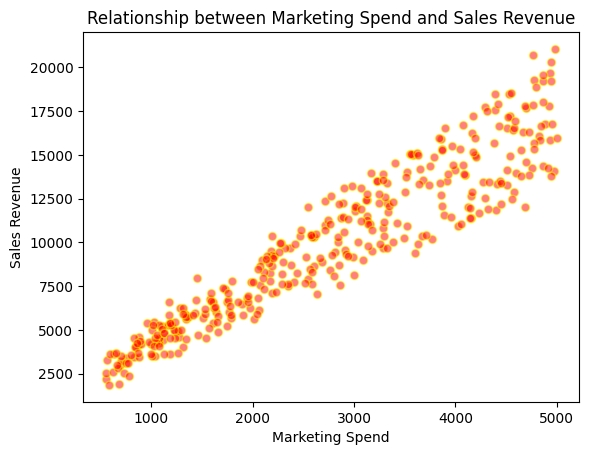

In [54]:
plt.scatter(df['Marketing_Spend'],df['Sales_Revenue'],alpha = 0.5,color='Red',edgecolors='Yellow')
plt.xlabel("Marketing Spend")
plt.ylabel("Sales Revenue")
plt.title("Relationship between Marketing Spend and Sales Revenue")
plt.show()

#Task 5: Histogram (Distribution)
<br>● Objective: Analyze the distribution of Customer_Age across the dataset.
<br>● Instructions: Plot a histogram for the Customer_Age column. Experiment by setting bins=10 and then bins=25 to see how the distribution changes.

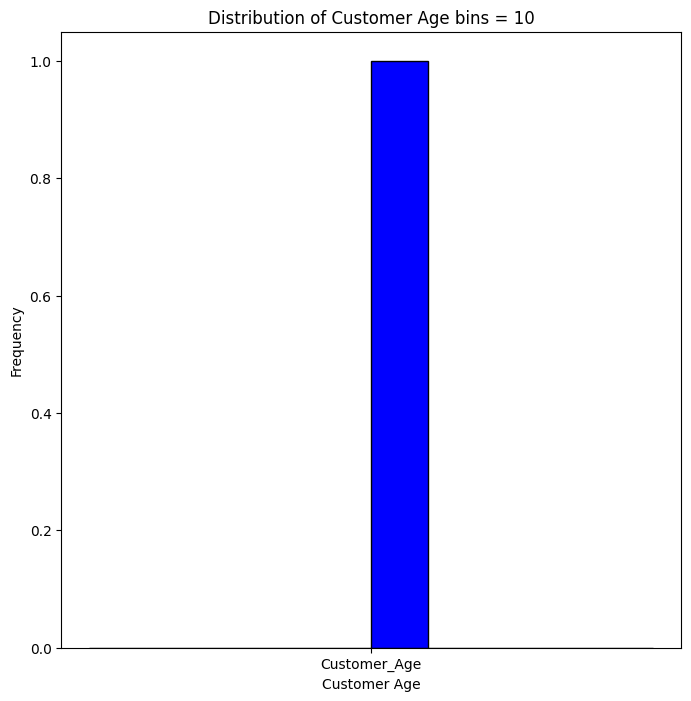

In [55]:
plt.figure(figsize=(8,8))
plt.hist(['Customer_Age'],bins=10,color='blue',edgecolor='black')
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age bins = 10")
plt.show()

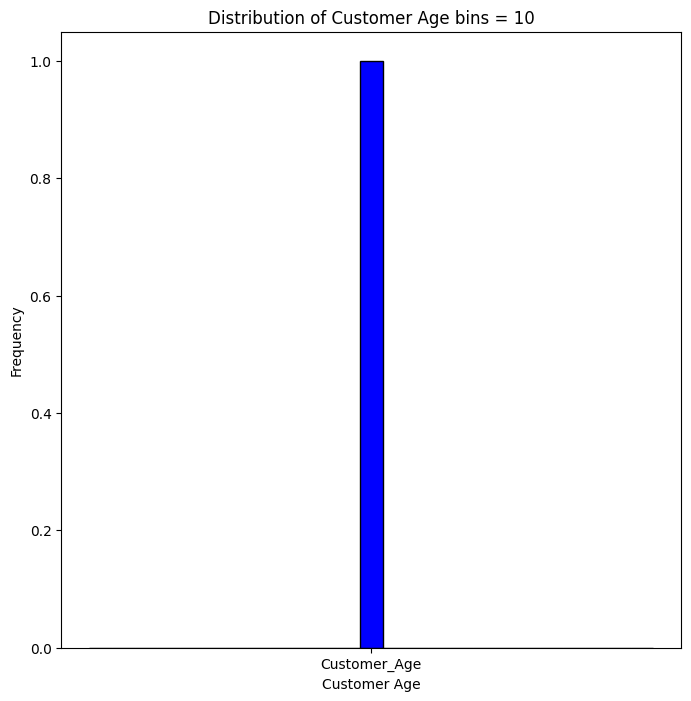

In [56]:
plt.figure(figsize=(8,8))
plt.hist(['Customer_Age'],bins=25,color='blue',edgecolor='black')
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age bins = 10")
plt.show()

#Task 6: Boxplot (Outliers & Spread)
<br>● Objective: Compare the distribution and identify outliers of Sales_Revenue across different Regions.
<br>● Instructions: Use Seaborn's sns.boxplot() with Region on the X-axis and Sales_Revenue on the Y-axis.

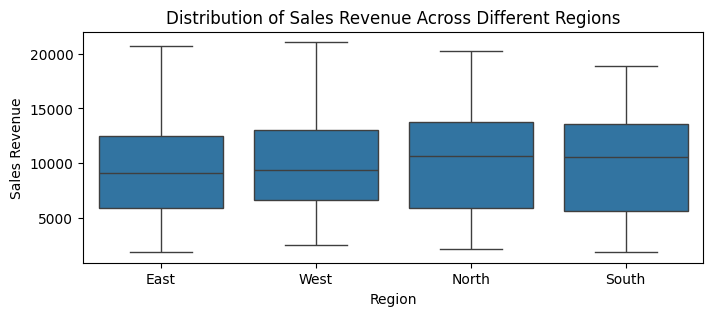

In [57]:
plt.figure(figsize=(8,3))
sns.boxplot(x='Region',y='Sales_Revenue',data=df)
plt.xlabel("Region")
plt.ylabel("Sales Revenue")
plt.title("Distribution of Sales Revenue Across Different Regions")
plt.show()

#Task 7: Heatmap (Correlation)
<br>● Objective: Find out which numerical features are most strongly correlated.
<br>● Instructions: Select only the numeric columns (Marketing_Spend, Sales_Revenue, Customer_Age, Store_Traffic) and compute their correlation matrix using df.corr(). Plot this matrix using Seaborn's sns.heatmap() with annotations turned on.

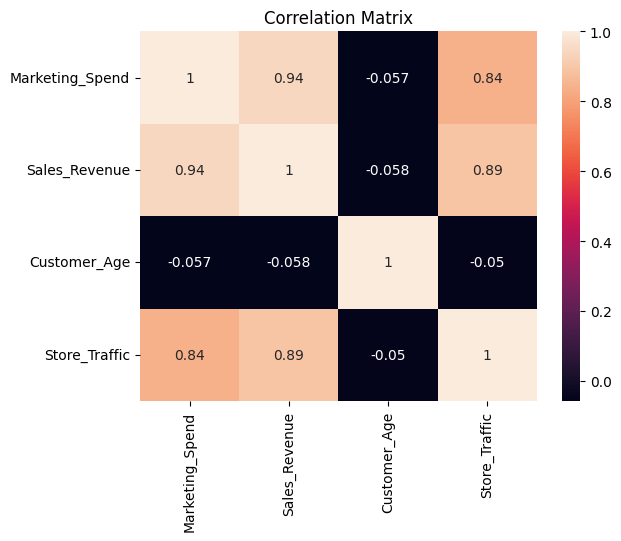

In [59]:
sns.heatmap(df[['Marketing_Spend','Sales_Revenue','Customer_Age','Store_Traffic']].corr(),annot=True)
plt.title("Correlation Matrix")
plt.show()

#Task 8: Bubble Chart (Multi-dimensional)
<br>● Objective: Visualize the relationship between Marketing, Sales, and Traffic simultaneously.
<br>● Instructions: Create a scatter plot where X is Marketing_Spend, Y is Sales_Revenue, and the size of the bubble (s parameter) is determined by Store_Traffic.

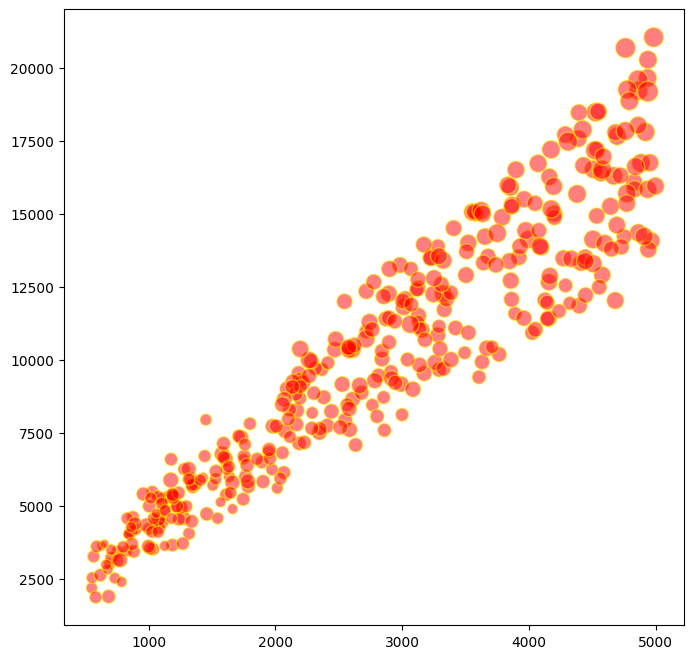

In [62]:
plt.figure(figsize=(8,8))
plt.scatter(df['Marketing_Spend'],df['Sales_Revenue'],s=df['Store_Traffic'],alpha = 0.5,color='Red',edgecolors='Yellow')

#Task 9: Area Chart (Cumulative Trend)
<br>● Objective: Show the cumulative Sales_Revenue over time stacked by Product_Category.
<br>● Instructions: Pivot your dataset so that dates are the index and product categories are the columns, filled with sales revenue. Use plt.stackplot() to visualize the volume over time.

In [63]:
pivot_df = df.pivot_table(
    index='Date',
    columns='Product_Category',
    values='Sales_Revenue',
    aggfunc='sum'
).sort_index()

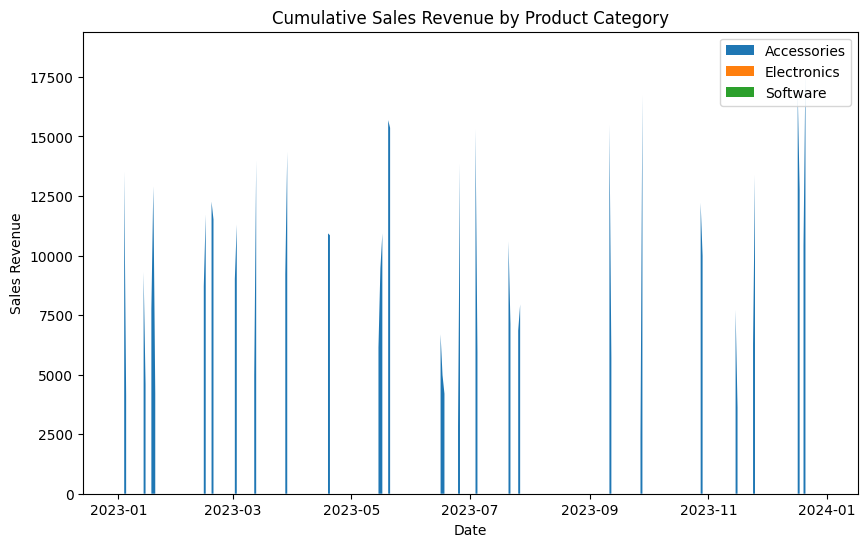

In [65]:
plt.figure(figsize=(10,6))
plt.stackplot(pivot_df.index,pivot_df.values.T,labels=pivot_df.columns)
plt.xlabel("Date")
plt.ylabel("Sales Revenue")
plt.title("Cumulative Sales Revenue by Product Category")
plt.legend(loc='upper right')
plt.show()